In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline

# ---- 1. Data ----

In [2]:
norm_callable = lambda size: rng.normal(size=size)

rng = np.random.default_rng(seed=42)
ar1 = np.array([1, 0.33])
ma1 = np.array([1, 0.9])

In [3]:
ARMA_11 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000, distrvs=norm_callable)
ArmaProcess(ar1, ma1).generate_sample

<bound method ArmaProcess.generate_sample of ArmaProcess([1.0, 0.33], [1.0, 0.9], nobs=100) at 0x1a5d0e742d0>

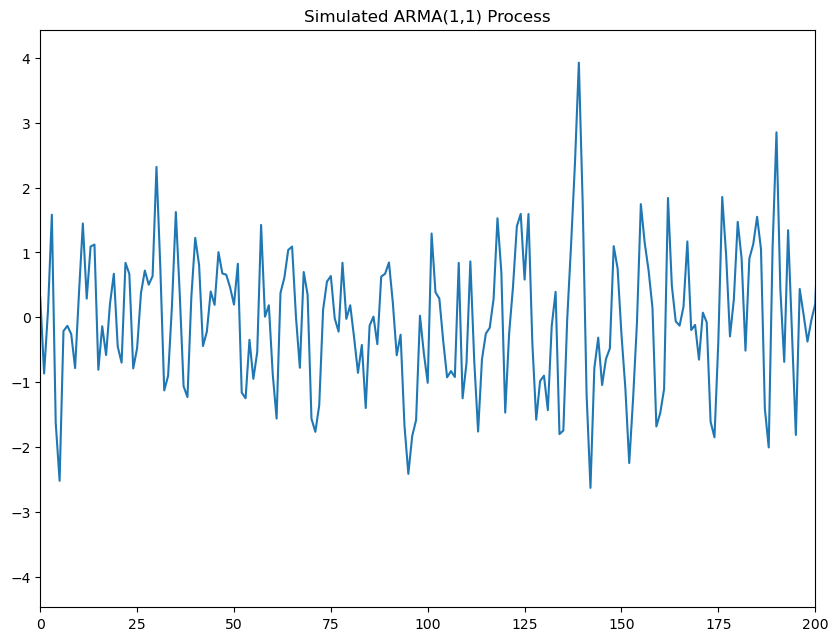

In [4]:
plt.plot(ARMA_11)
plt.title("Simulated ARMA(1,1) Process")
plt.xlim([0, 200])
plt.show()

In [5]:
# 2. Create matching datetime index (Daily frequency 'D')
time_index = pd.date_range(start="2026-09-01", periods=len(ARMA_11), freq="D")

# 3. Convert to a Pandas Time Series
time_series = pd.Series(ARMA_11, index=time_index)

print(time_series)

2026-09-01    0.304717
2026-09-02   -0.866295
2026-09-03    0.100343
2026-09-04    1.582858
2026-09-05   -1.626870
                ...   
2029-05-23    0.130468
2029-05-24    1.041217
2029-05-25    0.467717
2029-05-26    0.085478
2029-05-27    0.913233
Freq: D, Length: 1000, dtype: float64


In [15]:
time_series[0]

np.float64(0.30471707975443135)

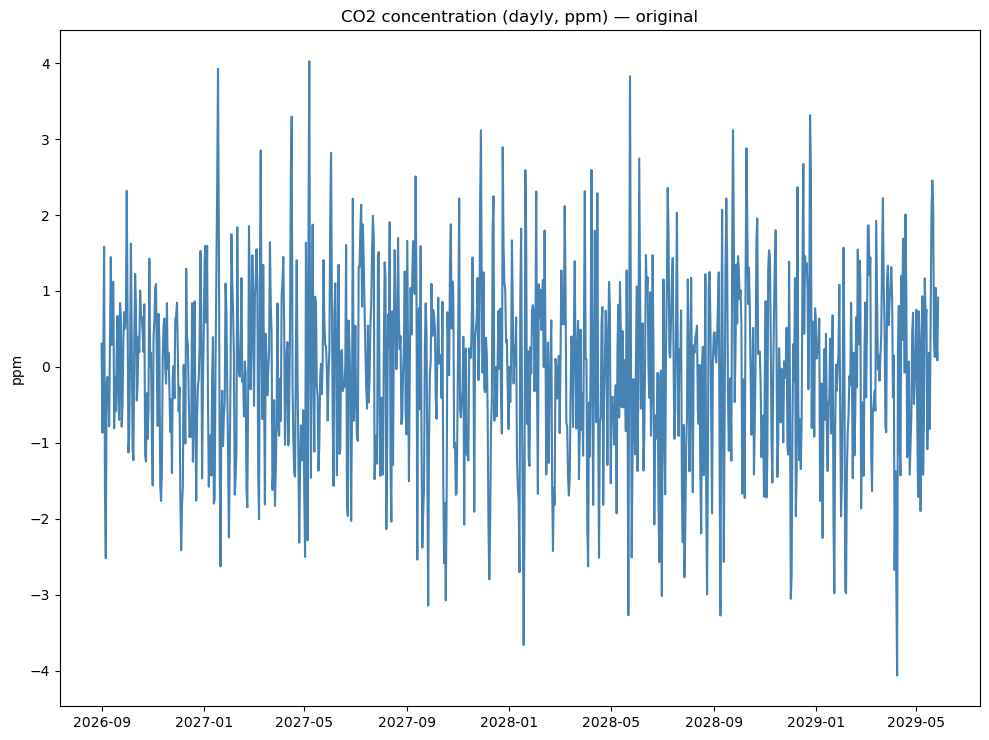

In [6]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(time_series, color="steelblue")
ax.set_title("CO2 concentration (dayly, ppm) — original")
ax.set_ylabel("ppm")
plt.tight_layout(); plt.show()


## ADFULLER TEST

Hypothesis Setup: Null Hypothesis (H₀): The series has a unit root (it is non-stationary).

Alternative Hypothesis (H₁): The series has no unit root (it is stationary).

[1] (https://www.statsmodels.org/devel/examples/notebooks/generated/stationarity_detrending_adf_kpss.html), 

[2] (https://www.geeksforgeeks.org/python/how-to-check-if-time-series-data-is-stationary-with-python/), 

[3] (https://www.youtube.com/watch?v=2cWsi6dfJ90)
     
The p-value Rule: If your p-value ≤ 0.05, you reject H₀ and conclude the series is stationary. 

If p > 0.05, your data is non-stationary

In [7]:
print("ADF on levels, p =", adfuller(time_series, autolag="AIC")[1])

ADF on levels, p = 8.644440719499159e-13


## PACF y ACF serie estacionaria 

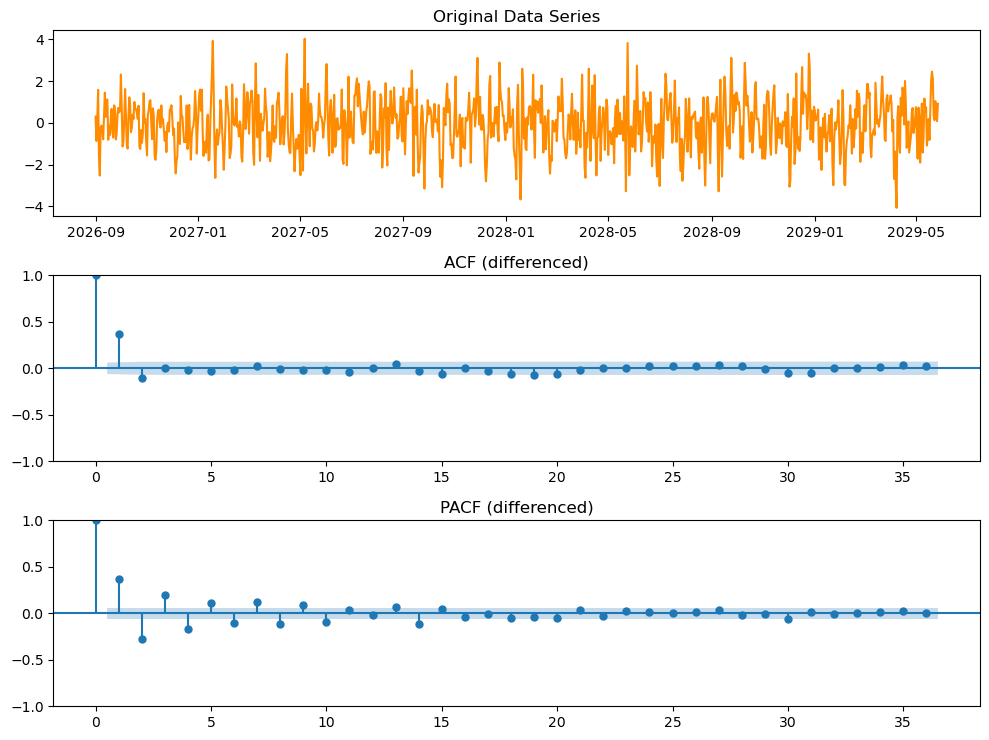

In [8]:
fig, axes = plt.subplots(3, 1)
axes[0].plot(time_series, color="darkorange")
axes[0].set_title("Original Data Series")
plot_acf(time_series,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(time_series, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

Como ambos (pacf y acf) tienen un comportamiento decreciente exponencial después del retardo 1, el orden de ARMA debería ser probado como p=q=1.

In [9]:
from statsmodels.tsa.arima.model import ARIMA
ARMA_model = ARIMA(time_series, order=(1,0,1), enforce_stationarity=False).fit()

print(ARMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1401.136
Date:                Sun, 13 Sep 2026   AIC                           2810.272
Time:                        22:22:15   BIC                           2829.895
Sample:                    09-01-2026   HQIC                          2817.731
                         - 05-27-2029                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0414      0.048     -0.864      0.388      -0.135       0.052
ar.L1         -0.2531      0.035     -7.255      0.000      -0.321      -0.185
ma.L1          0.9155      0.015     62.014      0.0

El modelo ajustado es : 
$$ y_t -\mu -  \phi_1 (y_{t-1}-\mu)=w_t+\theta_1w_{t-1}$$

Con $\phi_1 = -0.2531$ y $\theta_1=0.9155$. $Var(w_t)=0.9687$. $E[y_t]=-0.0414$

In [21]:
time_series.values.mean()

np.float64(-0.041604479501809025)

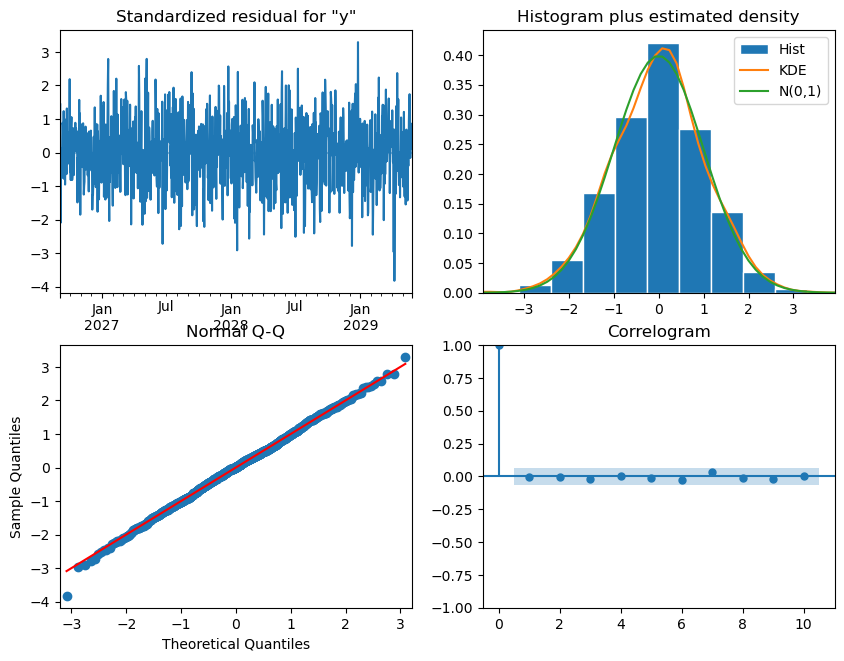

In [10]:
ARMA_model.plot_diagnostics()
plt.show()

In [11]:
time_series

2026-09-01    0.304717
2026-09-02   -0.866295
2026-09-03    0.100343
2026-09-04    1.582858
2026-09-05   -1.626870
                ...   
2029-05-23    0.130468
2029-05-24    1.041217
2029-05-25    0.467717
2029-05-26    0.085478
2029-05-27    0.913233
Freq: D, Length: 1000, dtype: float64

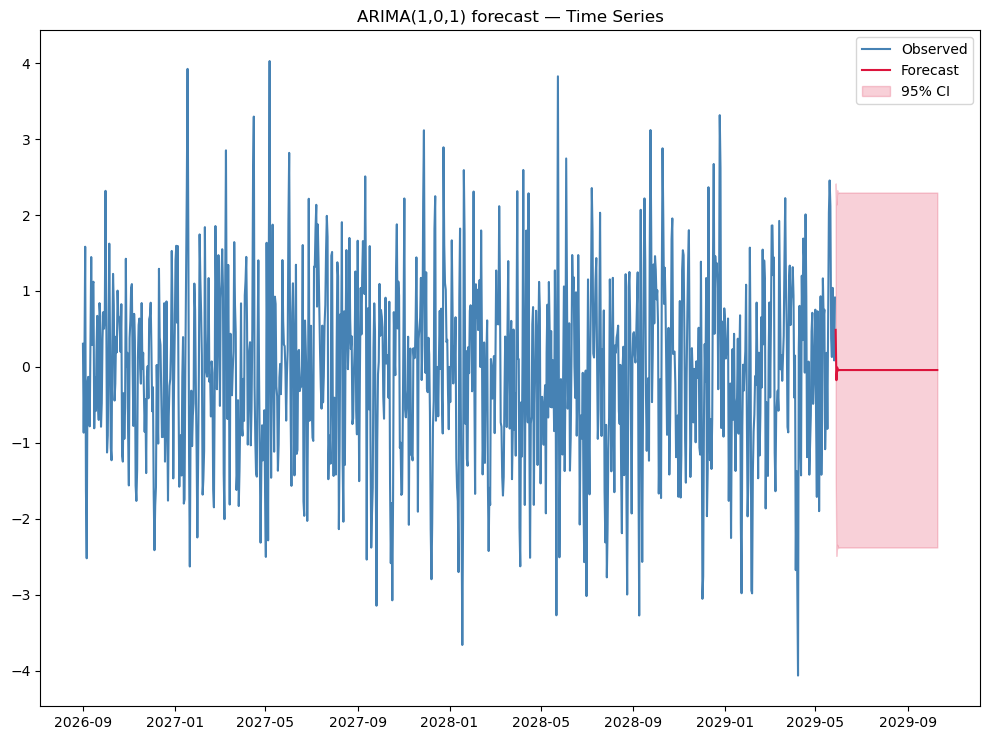

In [12]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 136
fc   = ARMA_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(time_series.index[-1], periods=steps + 1, freq="D")[1:]

fig, ax = plt.subplots()
ax.plot(time_series, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(1,0,1) forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()